# CONTENEDOR

In [1]:
from pathlib import Path
from contenedor_dask import CONTENEDOR_SECOP

container = CONTENEDOR_SECOP()

# VARIABLES

In [2]:
BASE_URL = "https://www.datos.gov.co/resource/p6dx-8zbt.csv"

DATA_DIR = Path(
    r"C:\Users\ser_s\Desktop\Maestria Analitica\Big Data\Big_Data\Big_Data_Grupo_6\Taller2\Cuadernillos\datos\secop_chunks"
)

# CARGA DE ARCHIVOS

In [4]:
from pathlib import Path
from contenedor_dask import CONTENEDOR_SECOP

container = CONTENEDOR_SECOP()

BASE_URL = "https://www.datos.gov.co/resource/p6dx-8zbt.csv"

DATA_DIR = Path(
    r"C:\Users\ser_s\Desktop\Maestria Analitica\Big Data\Big_Data\Big_Data_Grupo_6\Taller2\Cuadernillos\datos\secop_chunks"
)

resumen_descarga = container.descargar_dataset_secop(
    base_url=BASE_URL,
    data_dir=DATA_DIR,
    total_filas=8_410_000,
    chunk=100_000,
    max_workers=2
)

resumen_descarga.head()

Descargando 8,410,000 filas en chunks de 100,000
Carpeta destino: C:\Users\ser_s\Desktop\Maestria Analitica\Big Data\Big_Data\Big_Data_Grupo_6\Taller2\Cuadernillos\datos\secop_chunks
Offsets generados: 85
Workers: 2

[SKIP] Ya existe: secop_chunk_0000000.csv
[SKIP] Ya existe: secop_chunk_0100000.csv
[SKIP] Ya existe: secop_chunk_0200000.csv
[SKIP] Ya existe: secop_chunk_0300000.csv
[SKIP] Ya existe: secop_chunk_0400000.csv
[SKIP] Ya existe: secop_chunk_0500000.csv
[SKIP] Ya existe: secop_chunk_0600000.csv
[SKIP] Ya existe: secop_chunk_0700000.csv
[SKIP] Ya existe: secop_chunk_0900000.csv
[SKIP] Ya existe: secop_chunk_0800000.csv
[SKIP] Ya existe: secop_chunk_1000000.csv
[SKIP] Ya existe: secop_chunk_1200000.csv
[SKIP] Ya existe: secop_chunk_1100000.csv
[SKIP] Ya existe: secop_chunk_1300000.csv
[SKIP] Ya existe: secop_chunk_1400000.csv
[SKIP] Ya existe: secop_chunk_1500000.csv
[SKIP] Ya existe: secop_chunk_1600000.csv
[SKIP] Ya existe: secop_chunk_1700000.csv
[SKIP] Ya existe: secop_chu

,offset,filas,columnas,mem_mb,ruta,estado
0,0,None,None,None,C:\Users\ser_s\Desktop\Maestria Analitica\Big ...,existente
1,100000,None,None,None,C:\Users\ser_s\Desktop\Maestria Analitica\Big ...,existente
2,200000,None,None,None,C:\Users\ser_s\Desktop\Maestria Analitica\Big ...,existente
3,300000,None,None,None,C:\Users\ser_s\Desktop\Maestria Analitica\Big ...,existente
4,400000,None,None,None,C:\Users\ser_s\Desktop\Maestria Analitica\Big ...,existente


# 1. ANÁLISIS PREELIMINAR


## 1.1. Pre-procesamiento de los datos

### Carga de datos

In [3]:
ddf = container.cargar_dask_dataframe(DATA_DIR)

Dask DataFrame cargado correctamente.

Información general
------------------------------------------------------------
Número de particiones: 85

Filas por partición estimadas:
0     100000
1     100000
2     100000
3     100000
4     100000
       ...  
80    100000
81    100000
82    100000
83    100000
84     11769
Length: 85, dtype: int64

Tipos de datos:
entidad                           string
nit_entidad                       string
departamento_entidad              string
ciudad_entidad                    string
ordenentidad                      string
codigo_pci                        string
id_del_proceso                    string
referencia_del_proceso            string
ppi                               string
id_del_portafolio                 string
nombre_del_procedimiento          string
descripci_n_del_procedimiento     string
fase                              string
fecha_de_publicacion_del          string
fecha_de_ultima_publicaci         string
fecha_de_publicacion_f

In [21]:
print(f'Total de columnas disponibles: {len(ddf.columns)}')
print('-' * 65)
for col in sorted(ddf.columns):
    ejemplo = ddf[col].dropna()
    primero = ejemplo.head(1)
    if not primero.empty:
        ej_str = str(primero.iloc[0])[:45]
    else:
        ej_str = 'N/A'
    print(f'  {col:<45} -> {ej_str}')

Total de columnas disponibles: 59
-----------------------------------------------------------------
  categorias_adicionales                        -> No definido
  ciudad_de_la_unidad_de                        -> Bogotá
  ciudad_entidad                                -> Bogotá
  ciudad_proveedor                              -> No Definido
  codigo_categoria_unspsc                       -> V1.80111500
  codigo_entidad                                -> 700474109
  codigo_pci                                    -> Centralizada
  codigoproveedor                               -> No Definido
  conteo_de_respuestas_a_ofertas                -> 0
  departamento                                  -> Distrito Capital de Bogotá
  departamento_proveedor                        -> No Definido
  descripci_n_del_procedimiento                 -> TS_MERCADO_2022_GEIH_TH Prestación de servici
  duracion                                      -> 344
  estado_adjudicacion                           -> No
  estad

c:\Users\ser_s\anaconda3\envs\dask\Lib\site-packages\dask\dataframe\core.py:8393: UserWarning: Insufficient elements for `head`. 1 elements requested, only 0 elements available. Try passing larger `npartitions` to `head`.
  warnings.warn(


  fecha_de_publicacion_fase                     -> N/A
  fecha_de_publicacion_fase_1                   -> 2022-11-08T00:00:00.000
  fecha_de_publicacion_fase_2                   -> 2019-04-29T00:00:00.000
  fecha_de_publicacion_fase_3                   -> 2022-01-18T00:00:00.000
  fecha_de_recepcion_de                         -> 2025-07-25T00:00:00.000
  fecha_de_ultima_publicaci                     -> 2022-01-18T00:00:00.000
  fecha_publicacion                             -> 2022-01-18T00:00:00.000
  id_adjudicacion                               -> No Adjudicado
  id_del_portafolio                             -> CO1.BDOS.2503732
  id_del_proceso                                -> CO1.REQ.2577563
  id_estado_del_procedimiento                   -> 70
  justificaci_n_modalidad_de                    -> Servicios profesionales y apoyo a la gestión
  modalidad_contratacion                        -> Contratación directa
  nit_entidad                                   -> 899999027
  nit_provee

### Normalización de columnas

In [7]:
ddf = container.normalizar_columnas(ddf)
ddf = container.renombrar_columnas_semanticas(ddf)

Columnas normalizadas correctamente.
Columnas únicas: True
Columnas renombradas semánticamente:
nit_entidad -> nit_entidad
ciudad_entidad -> ciudad_entidad
departamento_proveedor -> departamento_proveedor
ciudad_proveedor -> ciudad_proveedor
fecha_adjudicacion -> fecha_adjudicacion
precio_base -> precio_base


### Selección de variables para Pregunta 1

In [8]:
ddf_q1_raw = container.seleccionar_variables_pregunta_1(ddf)

DataFrame auxiliar Pregunta 1 creado.
Columnas: ['departamento', 'valor_adjudicado', 'fecha_publicacion', 'estado_adjudicacion']


### Limpieza y transformación

In [9]:
ddf_q1_clean = container.limpiar_pregunta_1(ddf_q1_raw)

Departamentos normalizados semánticamente.
Limpieza y transformación Pregunta 1 finalizada.


In [10]:
ddf_q1_clean.head(10)

,departamento,valor_adjudicado,fecha_publicacion,estado_adjudicacion,anio_publicacion
0,BOGOTA D.C.,0,2022-01-18,NO,2022
1,BOGOTA D.C.,0,2024-03-08,NO,2024
2,BOGOTA D.C.,40000,2025-07-23,SI,2025
3,ANTIOQUIA,0,2026-01-18,NO,2026
4,BOGOTA D.C.,0,2024-11-06,NO,2024
5,CALDAS,0,2021-08-05,NO,2021
6,BOGOTA D.C.,0,2026-01-22,NO,2026
7,PUTUMAYO,0,2025-05-16,NO,2025
8,CUNDINAMARCA,0,2024-08-06,NO,2024
9,ANTIOQUIA,0,2025-10-31,NO,2025


### Diagnóstico

In [11]:
diagnostico_q1 = container.diagnosticar_pregunta_1(ddf_q1_clean)
diagnostico_q1


DIAGNÓSTICO DE CALIDAD — PREGUNTA 1


,Indicador,Valor
0,total_registros,8411769
1,nulos_valor_adjudicado,0
2,valores_cero,7621779
3,valores_negativos,0
4,fechas_invalidas,94544
5,anios_invalidos,94544
6,departamento_no_definido,559254
7,procesos_adjudicados_si,793810
8,procesos_adjudicados_no,7617959


In [12]:
ddf_q1_analitico = ddf_q1_clean[
    (ddf_q1_clean["estado_adjudicacion"] == "SI") &
    (ddf_q1_clean["valor_adjudicado"] > 0) &
    (ddf_q1_clean["departamento"] != "NO DEFINIDO") &
    (ddf_q1_clean["anio_publicacion"].notnull())
]

In [13]:
ddf_q1_analitico

,departamento,valor_adjudicado,fecha_publicacion,estado_adjudicacion,anio_publicacion
npartitions=85,,,,,
,object,Int64,datetime64[s],object,Int64
,...,...,...,...,...
...,...,...,...,...,...
,...,...,...,...,...
,...,...,...,...,...


In [19]:
diagnostico_clean_q1 = container.diagnosticar_pregunta_1(ddf_q1_analitico)
diagnostico_clean_q1


DIAGNÓSTICO DE CALIDAD — PREGUNTA 1


,Indicador,Valor
0,total_registros,767718
1,nulos_valor_adjudicado,0
2,valores_cero,0
3,valores_negativos,0
4,fechas_invalidas,0
5,anios_invalidos,0
6,departamento_no_definido,0
7,procesos_adjudicados_si,767718
8,procesos_adjudicados_no,0


In [15]:
ddf_q1_analitico.head(10)

,departamento,valor_adjudicado,fecha_publicacion,estado_adjudicacion,anio_publicacion
2,BOGOTA D.C.,40000,2025-07-23,SI,2025
10,BOGOTA D.C.,37842000,2025-07-31,SI,2025
15,SANTANDER,305644297,2025-12-30,SI,2025
36,NARINO,82076690,2025-11-13,SI,2025
46,BOGOTA D.C.,1634865104,2024-07-16,SI,2024
50,BOGOTA D.C.,3422164000,2020-06-24,SI,2020
60,SANTANDER,9080000,2025-07-03,SI,2025
83,BOGOTA D.C.,11312665,2020-02-10,SI,2020
113,BOGOTA D.C.,1005706033,2018-06-08,SI,2018
123,ANTIOQUIA,39857999,2025-09-04,SI,2025


In [16]:
print("\nRegistros del universo analítico:")
print(f"{ddf_q1_analitico.shape[0].compute():,}")

print("\nMuestra universo analítico:")
ddf_q1_analitico.head(10)


Registros del universo analítico:
767,718

Muestra universo analítico:


,departamento,valor_adjudicado,fecha_publicacion,estado_adjudicacion,anio_publicacion
2,BOGOTA D.C.,40000,2025-07-23,SI,2025
10,BOGOTA D.C.,37842000,2025-07-31,SI,2025
15,SANTANDER,305644297,2025-12-30,SI,2025
36,NARINO,82076690,2025-11-13,SI,2025
46,BOGOTA D.C.,1634865104,2024-07-16,SI,2024
50,BOGOTA D.C.,3422164000,2020-06-24,SI,2020
60,SANTANDER,9080000,2025-07-03,SI,2025
83,BOGOTA D.C.,11312665,2020-02-10,SI,2020
113,BOGOTA D.C.,1005706033,2018-06-08,SI,2018
123,ANTIOQUIA,39857999,2025-09-04,SI,2025


In [17]:
ddf_q1_analitico = container.crear_universo_analitico_q1(ddf_q1_clean)

tabla_top10, total_nacional, resultado_top5 = container.ejecutar_analisis_pregunta_1(
    ddf_q1_analitico
)

tabla_top10

Universo analítico Pregunta 1 creado.

ANÁLISIS PREGUNTA 1 — CONCENTRACIÓN TERRITORIAL
Total nacional adjudicado: 4,262,893.97 Billones COP
Concentración Top 5: 97.57%
Conclusión: los 5 primeros departamentos superan el 60% del gasto.


,ranking,departamento,valor_total_adjudicado,valor_escala,valor_formateado,porcentaje_total,porcentaje_acumulado,dif_vs_promedio,indice_relativo
0,1,SANTANDER,3423792285416176216,3.423792e+06,"3,423,792.29 Billones COP",80.3161,80.3161,70.3301,8.0428
1,2,ANTIOQUIA,456717743851984083,4.567177e+05,"456,717.74 Billones COP",10.7138,91.0299,0.7277,1.0729
2,3,ATLANTICO,137707918650984754,1.377079e+05,"137,707.92 Billones COP",3.2304,94.2603,-6.7557,0.3235
3,4,CUNDINAMARCA,77039270980945482,7.703927e+04,"77,039.27 Billones COP",1.8072,96.0675,-8.1789,0.1810
4,5,BOLIVAR,64018887900249477,6.401889e+04,"64,018.89 Billones COP",1.5018,97.5693,-8.4843,0.1504
5,6,BOYACA,37681412809142638,3.768141e+04,"37,681.41 Billones COP",0.8839,98.4532,-9.1021,0.0885
6,7,VALLE DEL CAUCA,24215964446841688,2.421596e+04,"24,215.96 Billones COP",0.5681,99.0213,-9.4180,0.0569
7,8,BOGOTA D.C.,20545512660108477,2.054551e+04,"20,545.51 Billones COP",0.4820,99.5033,-9.5041,0.0483
8,9,CESAR,8725010078424970,8.725010e+03,"8,725.01 Billones COP",0.2047,99.7079,-9.7814,0.0205
9,10,SUCRE,6517073242745261,6.517073e+03,"6,517.07 Billones COP",0.1529,99.8608,-9.8332,0.0153


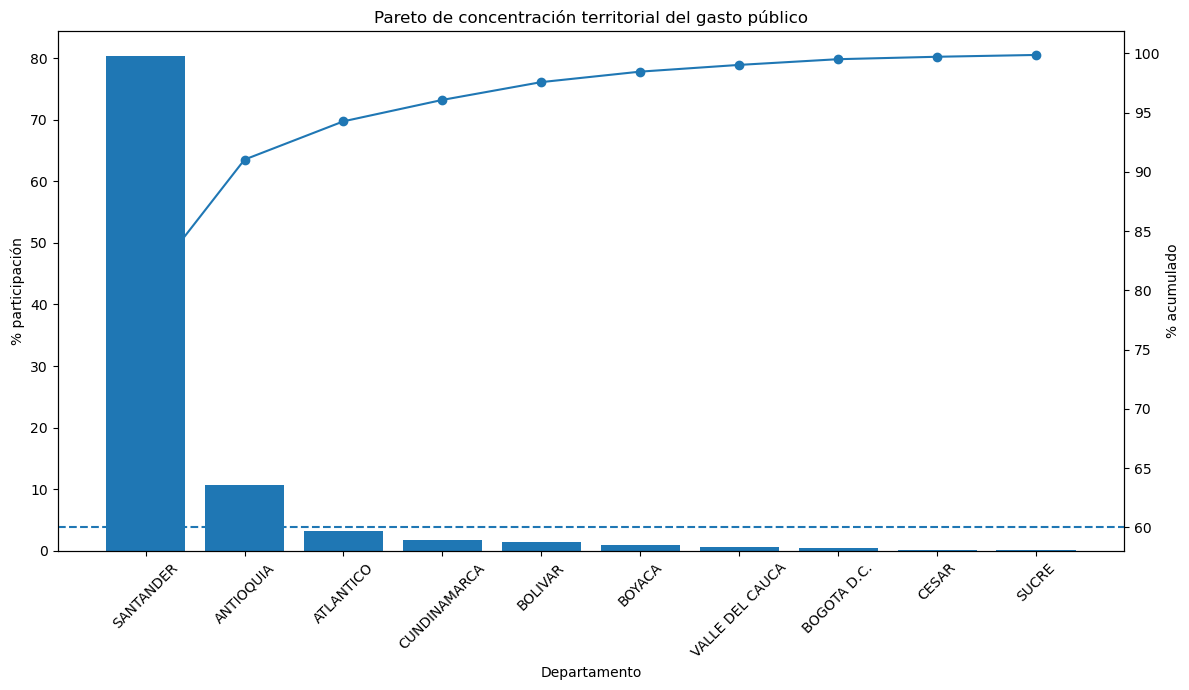

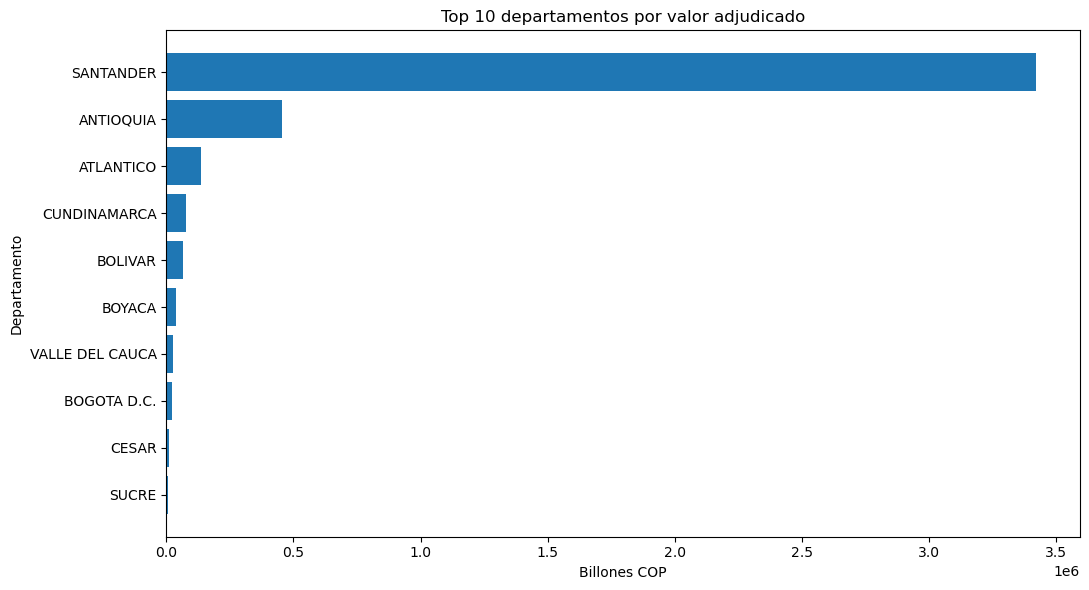

In [18]:
container.graficar_pareto_q1(tabla_top10)

container.graficar_top10_valor_q1(tabla_top10)